In [ ]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

import scipy.integrate as integrate

In [ ]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [ ]:
#initialise parameters
par = par()
par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
par.files.partfile_in = "/home/jamesdr/scratch/miniramses/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/partfile_out.std"
par.files.halofile_in = "/home/jamesdr/scratch/miniramses/output_00011"
par.files.halofile_out = "/home/jamesdr/usrp2024/halofile_out.std"

In [7]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/miniramses/)', par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [ ]:
def read_displaced_particles(file):

    Lbox   = unit_l / (3.086e24) * par.cosmo.h0
    N_chunk = 1
    L_chunk = Lbox/N_chunk
    
    Om = i.omega_m
    z  = par.cosmo.z
    
    f = open(file, 'r')

    #header
    p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
    p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
    #gas
    p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
    p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
    #dm
    p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
    p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
    #stars
    p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
    p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

    #convert to Mpc/h
    p_gas['x']=Lbox*(p_gas['x']+0.5)
    p_gas['y']=Lbox*(p_gas['y']+0.5)
    p_gas['z']=Lbox*(p_gas['z']+0.5)
    p_dm['x']=Lbox*(p_dm['x']+0.5)
    p_dm['y']=Lbox*(p_dm['y']+0.5)
    p_dm['z']=Lbox*(p_dm['z']+0.5)
    p_star['x']=Lbox*(p_star['x']+0.5)
    p_star['y']=Lbox*(p_star['y']+0.5)
    p_star['z']=Lbox*(p_star['z']+0.5)

    #convert to Mstar/h
    print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
    p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
    print('Reading tipsy-file done!')
    
    #split particles into chunks
    p_gas_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                p_gas_list += [p_gas[ID_gas]]
                
    #split particles into chunks
    p_dm_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                p_dm_list += [p_dm[ID_dm]]
                
    #split particles into chunks
    p_star_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                p_star_list += [p_star[ID_star]]
    
    return p_header, p_gas_list, p_dm_list, p_star_list

In [ ]:
p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/partfile_out.std")

In [7]:
from astropy.cosmology import FlatLambdaCDM
Om0 = 0.308
Ob0 = 0.0486
cosmo = FlatLambdaCDM(H0=67.74, Om0 = Om0, Ob0 = Ob0, Tcmb0 = 2.7255, Neff = 3.046) #Neutrino mass is 0 by default
c_km = 3e5 #km/s
sigmat = 6.98426e-74 * (cosmo.h)**2 #(Mpc/h)^2
m_p = 1.67262192e-27/1.989e+30 * cosmo.h #Msol/h
bins = 200

electrons_per_particle = displaced_gas[0]['mass'][0] / m_p
Mpc_per_pixel = unit_l_in_Mpc_per_h/bins

In [8]:
weights = electrons_per_particle * sigmat / c_km * displaced_gas[0]['vz'] / ((Mpc_per_pixel)**2.0)

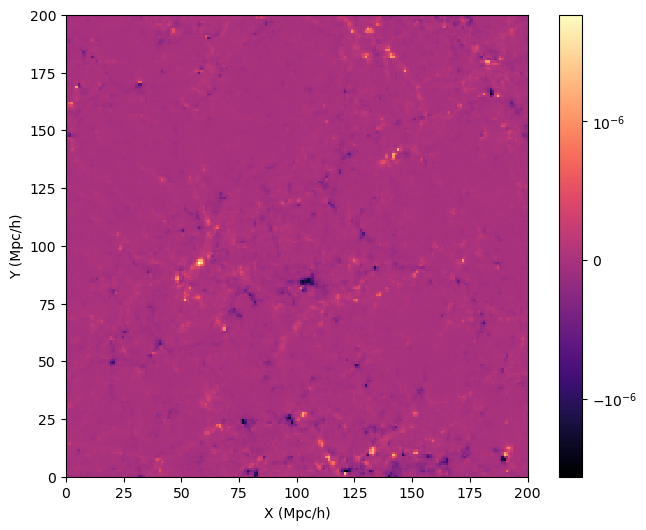

In [9]:
ksz_hist, ksz_xedges, ksz_yedges = np.histogram2d(displaced_gas[0]['x'],displaced_gas[0]['y'],density=False, weights=weights,bins=bins)
ksz_hist = ksz_hist.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(ksz_hist), vmax=np.max(ksz_hist))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(ksz_hist, interpolation='nearest', origin='lower', extent=[ksz_xedges[0], ksz_xedges[-1], ksz_yedges[0], ksz_yedges[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

plt.show()

In [10]:
#Now we do the same thing for the DMO simulations, applying an Ob/Om correction factor

baryon_correction_factor = Ob0/Om0

electrons_per_dm_particle = displaced_dm[0]['mass'][0] / m_p

dm_weights = baryon_correction_factor * electrons_per_dm_particle * sigmat / c_km * displaced_dm[0]['vz'] / ((Mpc_per_pixel)**2.0)

6.5958766975047156e+66


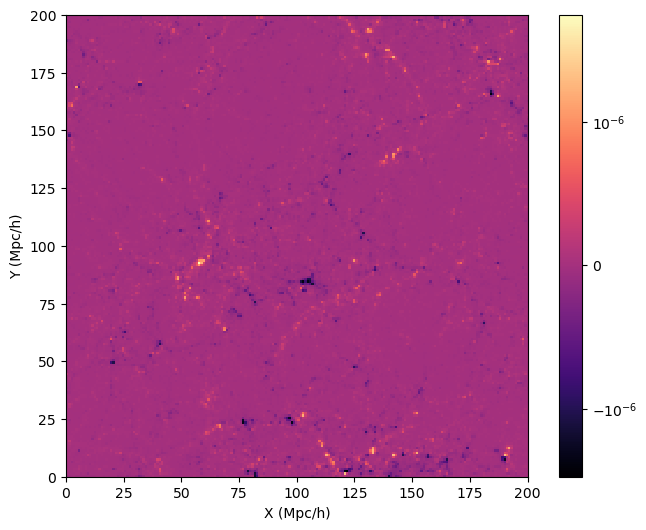

In [11]:
ksz_hist_dm, ksz_xedges_dm, ksz_yedges_dm = np.histogram2d(displaced_dm[0]['x'],displaced_dm[0]['y'],density=False, weights=dm_weights,bins=bins)
ksz_hist_dm = ksz_hist_dm.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(ksz_hist_dm), vmax=np.max(ksz_hist_dm))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(ksz_hist_dm, interpolation='nearest', origin='lower', extent=[ksz_xedges_dm[0], ksz_xedges_dm[-1], ksz_yedges_dm[0], ksz_yedges_dm[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

plt.show()

In [12]:
#Now we do the Osato method

from baryonification.baryonification.io import read_halo_file
haloes = read_halo_file(par)

In [13]:
from scipy import spatial

p_tree = spatial.cKDTree(list(zip(displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])), leafsize=100)

In [14]:
iphalo = np.zeros(len(displaced_gas[0]['x']))
for i in range(len(haloes[0]['Mvir'])):
    ip   = np.array(p_tree.query_ball_point((haloes[0]['x'][i],haloes[0]['y'][i],haloes[0]['z'][i]), haloes[0]['rvir'][i]))
    if len(ip)>0:
        iphalo[ip] = i

In [15]:
#We go halo by halo, assigning every particle in each halo the velocity of that halo

weights_Osato = np.zeros(len(displaced_gas[0]['x']))

weights_haloes = electrons_per_particle * sigmat / c_km * haloes[0]['vz'] / ((Mpc_per_pixel)**2.0)

[-2.28711362e-11 -5.60610588e-11  1.81844013e-12 ... -1.56129910e-11
  5.00942646e-11 -1.57532351e-11]


In [17]:
for i in range(len(displaced_gas[0]['x'])):
    if i % 1000000 == 0:
        print(i)
    iphaloi = iphalo[i].astype(int)
    if iphaloi == 0:
        pass
    else:
        weights_Osato[i] += weights_haloes[iphaloi]
    
print(weights_Osato)

0
1000000
2000000
3000000
4000000
5000000
6000000
7000000
8000000
9000000
10000000
11000000
12000000
13000000
14000000
15000000
16000000
17000000
18000000
19000000
20000000
21000000
22000000
23000000
24000000
25000000
26000000
27000000
28000000
29000000
30000000
31000000
32000000
33000000
34000000
35000000
36000000
37000000
38000000
39000000
40000000
41000000
42000000
43000000
44000000
45000000
46000000
47000000
48000000
49000000
50000000
51000000
52000000
53000000
54000000
55000000
56000000
57000000
58000000
59000000
60000000
61000000
62000000
63000000
64000000
65000000
66000000
67000000
68000000
69000000
70000000
71000000
72000000
73000000
74000000
75000000
76000000
77000000
78000000
79000000
80000000
81000000
82000000
83000000
84000000
85000000
86000000
87000000
88000000
89000000
90000000
91000000
92000000
93000000
94000000
95000000
96000000
97000000
98000000
99000000
100000000
101000000
102000000
103000000
104000000
105000000
106000000
107000000
108000000
109000000
110000000
111000

In [18]:
print(len(weights_Osato))
print(len(displaced_dm[0]['y']))

128270453
134217728


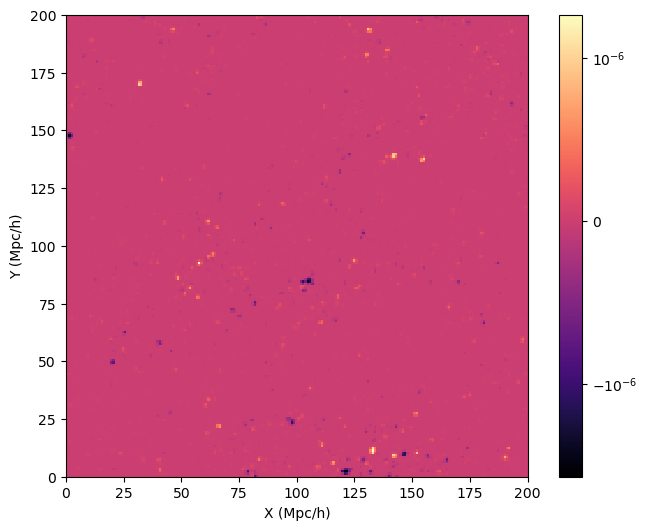

In [19]:
ksz_hist_Osato, ksz_xedges_Osato, ksz_yedges_Osato = np.histogram2d(displaced_gas[0]['x'],displaced_gas[0]['y'],density=False, weights=weights_Osato,bins=bins)
ksz_hist_Osato = ksz_hist_Osato.T

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(ksz_hist_Osato), vmax=np.max(ksz_hist_Osato))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(ksz_hist_Osato, interpolation='nearest', origin='lower', extent=[ksz_xedges_Osato[0], ksz_xedges_Osato[-1], ksz_yedges_Osato[0], ksz_yedges_Osato[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

# Adding labels and title
plt.xlabel('X (Mpc/h)')
plt.ylabel('Y (Mpc/h)')

plt.show()